<a href="https://colab.research.google.com/github/Hosny100/-/blob/main/CNN_LSTM_Gesture_SmartHome.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏠 CNN-LSTM: Gesture Recognition for Smart Home Control
### Fully Synthetic (Generated) Dataset

**Idea:** Simulate hand gesture trajectories (x, y position over time) for 6 smart home commands.  
Each gesture = a sequence of (x,y) coordinates → CNN extracts local motion patterns → LSTM captures the full trajectory shape.

| Gesture | Smart Home Command |
|---------|-------------------|
| ➡️ Swipe Right | Turn ON lights |
| ⬅️ Swipe Left  | Turn OFF lights |
| ⬆️ Swipe Up    | Volume UP |
| ⬇️ Swipe Down  | Volume DOWN |
| 🔄 Circle      | Activate scene |
| ✋ Tap (zigzag)| Pause / Play |

---

## 📦 Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, BatchNormalization,
    LSTM, Dense, Dropout
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)
print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

TensorFlow : 2.19.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 🎲 Step 2: Generate Synthetic Gesture Data

Each gesture is a sequence of **50 (x,y) points** with realistic noise added.  
- Swipes: linear trajectory with slight curve  
- Circle: parametric sine/cosine  
- Tap/Zigzag: rapid oscillation

In [2]:
SEQ_LEN           = 50     # timesteps per gesture
SAMPLES_PER_CLASS = 800    # samples per gesture class
NOISE_STD         = 0.03   # realistic hand tremor noise

GESTURE_NAMES = [
    'Swipe Right',
    'Swipe Left',
    'Swipe Up',
    'Swipe Down',
    'Circle',
    'Tap/Zigzag'
]
NUM_CLASSES = len(GESTURE_NAMES)

def add_noise(seq, std=NOISE_STD):
    return seq + np.random.normal(0, std, seq.shape)

def random_scale_shift(seq):
    """Augment: random scale (0.8-1.2) and shift"""
    scale = np.random.uniform(0.8, 1.2)
    shift = np.random.uniform(-0.1, 0.1, 2)
    return seq * scale + shift

def gen_swipe_right(n=SAMPLES_PER_CLASS):
    data = []
    t = np.linspace(0, 1, SEQ_LEN)
    for _ in range(n):
        x = t                                          # left to right
        y = 0.5 + 0.05 * np.sin(np.pi * t)            # slight arc
        seq = add_noise(random_scale_shift(np.stack([x, y], axis=1)))
        data.append(seq)
    return np.array(data)

def gen_swipe_left(n=SAMPLES_PER_CLASS):
    data = []
    t = np.linspace(0, 1, SEQ_LEN)
    for _ in range(n):
        x = 1 - t                                      # right to left
        y = 0.5 + 0.05 * np.sin(np.pi * t)
        seq = add_noise(random_scale_shift(np.stack([x, y], axis=1)))
        data.append(seq)
    return np.array(data)

def gen_swipe_up(n=SAMPLES_PER_CLASS):
    data = []
    t = np.linspace(0, 1, SEQ_LEN)
    for _ in range(n):
        x = 0.5 + 0.05 * np.sin(np.pi * t)
        y = t                                          # bottom to top
        seq = add_noise(random_scale_shift(np.stack([x, y], axis=1)))
        data.append(seq)
    return np.array(data)

def gen_swipe_down(n=SAMPLES_PER_CLASS):
    data = []
    t = np.linspace(0, 1, SEQ_LEN)
    for _ in range(n):
        x = 0.5 + 0.05 * np.sin(np.pi * t)
        y = 1 - t                                      # top to bottom
        seq = add_noise(random_scale_shift(np.stack([x, y], axis=1)))
        data.append(seq)
    return np.array(data)

def gen_circle(n=SAMPLES_PER_CLASS):
    data = []
    t = np.linspace(0, 2 * np.pi, SEQ_LEN)
    for _ in range(n):
        r = np.random.uniform(0.2, 0.4)
        cx, cy = np.random.uniform(0.4, 0.6), np.random.uniform(0.4, 0.6)
        # Random start angle
        start = np.random.uniform(0, 2 * np.pi)
        x = cx + r * np.cos(t + start)
        y = cy + r * np.sin(t + start)
        seq = add_noise(np.stack([x, y], axis=1))
        data.append(seq)
    return np.array(data)

def gen_tap_zigzag(n=SAMPLES_PER_CLASS):
    data = []
    t = np.linspace(0, 1, SEQ_LEN)
    for _ in range(n):
        freq = np.random.uniform(3, 6)
        x = 0.5 + 0.3 * np.sin(2 * np.pi * freq * t)  # rapid oscillation
        y = 0.5 + 0.3 * np.cos(2 * np.pi * freq * t * 0.5)
        seq = add_noise(random_scale_shift(np.stack([x, y], axis=1)))
        data.append(seq)
    return np.array(data)

# Generate all classes
generators = [
    gen_swipe_right,
    gen_swipe_left,
    gen_swipe_up,
    gen_swipe_down,
    gen_circle,
    gen_tap_zigzag
]

X_list, y_list = [], []
for label, gen_fn in enumerate(generators):
    samples = gen_fn()
    X_list.append(samples)
    y_list.append(np.full(len(samples), label))
    print(f'✅ Generated {len(samples)} samples for: {GESTURE_NAMES[label]}')

X = np.concatenate(X_list).astype(np.float32)   # (N, 50, 2)
y = np.concatenate(y_list).astype(int)
print(f'\nTotal X shape : {X.shape}   → (samples, timesteps=50, features=2)')
print(f'Total y shape : {y.shape}')

✅ Generated 800 samples for: Swipe Right
✅ Generated 800 samples for: Swipe Left
✅ Generated 800 samples for: Swipe Up
✅ Generated 800 samples for: Swipe Down
✅ Generated 800 samples for: Circle
✅ Generated 800 samples for: Tap/Zigzag

Total X shape : (4800, 50, 2)   → (samples, timesteps=50, features=2)
Total y shape : (4800,)


## 🔍 Step 3: Visualize Generated Gestures

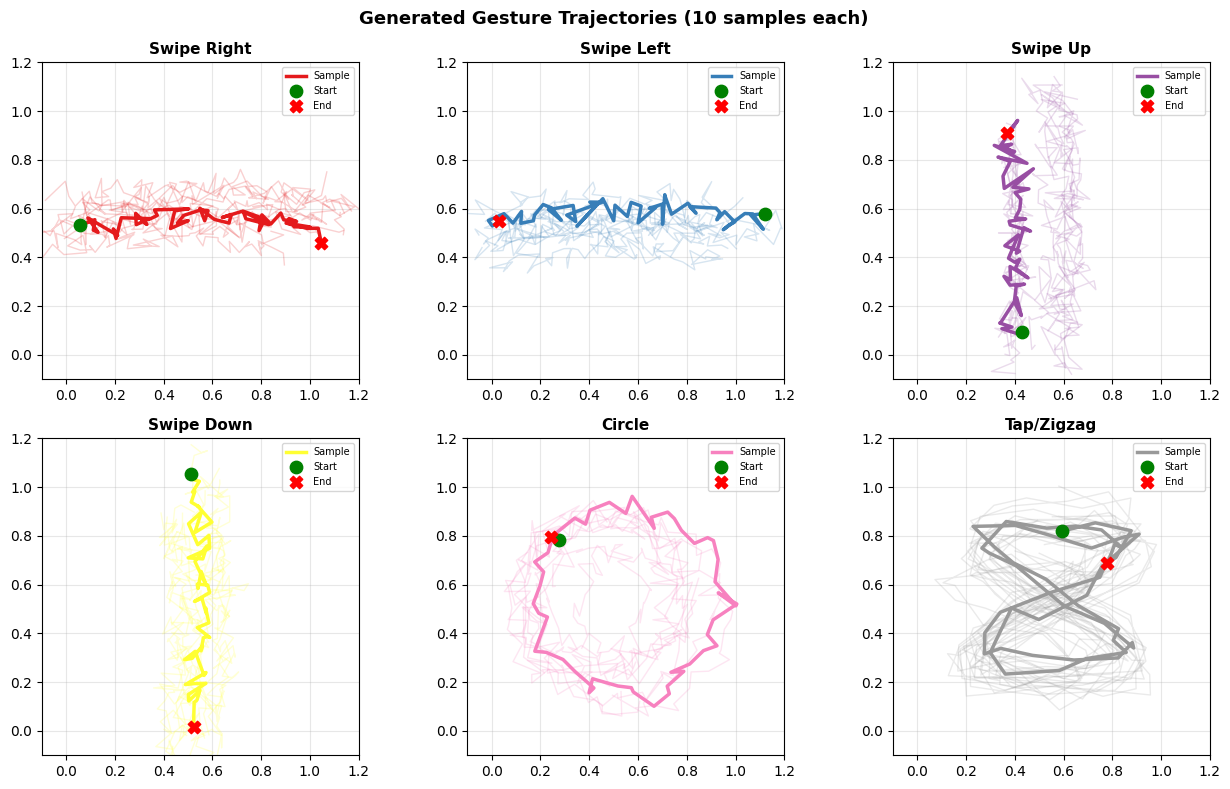

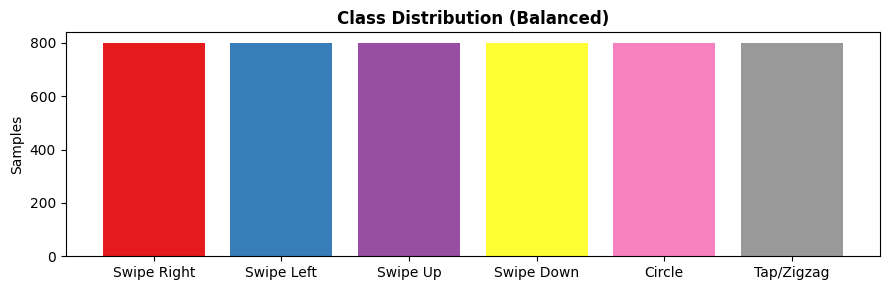

In [3]:
colors = plt.cm.Set1(np.linspace(0, 1, NUM_CLASSES))

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()

for cls_idx, (ax, name, color) in enumerate(zip(axes, GESTURE_NAMES, colors)):
    cls_samples = X[y == cls_idx]
    # Plot 10 samples lightly + 1 bold
    for i in range(10):
        ax.plot(cls_samples[i, :, 0], cls_samples[i, :, 1],
                color=color, alpha=0.2, linewidth=1)
    ax.plot(cls_samples[0, :, 0], cls_samples[0, :, 1],
            color=color, linewidth=2.5, label='Sample')
    # Start & end markers
    ax.scatter(*cls_samples[0, 0, :], color='green', zorder=5, s=80, label='Start')
    ax.scatter(*cls_samples[0, -1, :], color='red',   zorder=5, s=80, marker='X', label='End')
    ax.set_title(f'{name}', fontweight='bold', fontsize=11)
    ax.set_xlim(-0.1, 1.2)
    ax.set_ylim(-0.1, 1.2)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Generated Gesture Trajectories (10 samples each)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Class distribution
plt.figure(figsize=(9, 3))
unique, counts = np.unique(y, return_counts=True)
plt.bar(GESTURE_NAMES, counts, color=colors)
plt.title('Class Distribution (Balanced)', fontweight='bold')
plt.ylabel('Samples')
plt.tight_layout()
plt.show()

## ⚙️ Step 4: Preprocessing

In [4]:
# Normalize x,y to [-1, 1] using training stats
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

mean = X_train_raw.mean(axis=(0, 1), keepdims=True)
std  = X_train_raw.std(axis=(0, 1),  keepdims=True) + 1e-8

X_train = (X_train_raw - mean) / std
X_test  = (X_test_raw  - mean) / std

y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  NUM_CLASSES)

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'y_train : {y_train_cat.shape}')

X_train : (3840, 50, 2)
X_test  : (960, 50, 2)
y_train : (3840, 6)


## 🏗️ Step 5: Build CNN-LSTM Model

```
Input  (50 timesteps, 2 features: x,y)
  ↓  Conv1D(64)  → BN → Conv1D(64)  → BN → MaxPool   ← detect local motion patterns
  ↓  Conv1D(128) → BN → MaxPool                        ← higher-level shape features
  ↓  LSTM(128) → LSTM(64)                              ← model full trajectory
  ↓  Dense(64) → Dense(6, softmax)                    ← classify gesture
```

In [5]:
def build_cnn_lstm(seq_len=SEQ_LEN, n_features=2, n_classes=NUM_CLASSES):
    model = Sequential([
        # ── CNN Block 1 ────────────────────────────────────
        Conv1D(64, kernel_size=3, padding='same', activation='relu',
               input_shape=(seq_len, n_features)),
        BatchNormalization(),
        Conv1D(64, kernel_size=3, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        # ── CNN Block 2 ────────────────────────────────────
        Conv1D(128, kernel_size=3, padding='same', activation='relu'),
        BatchNormalization(),
        Conv1D(128, kernel_size=3, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        # ── LSTM Block ─────────────────────────────────────
        LSTM(128, return_sequences=True),
        Dropout(0.4),
        LSTM(64, return_sequences=False),
        Dropout(0.4),

        # ── Classifier ─────────────────────────────────────
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(n_classes, activation='softmax')
    ], name='CNN_LSTM_Gesture')
    return model

model = build_cnn_lstm()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_LSTM_Gesture"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 50, 64)         │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 50, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 50, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 25, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 25, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 25, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 25, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 12, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273,862 (1.04 MB)

 Trainable params: 273,094 (1.04 MB)

 Non-trainable params: 768 (3.00 KB)

## 🚀 Step 6: Compile & Train

In [6]:
model.compile(
    optimizer=Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-6, verbose=1)
]

history = model.fit(
    X_train, y_train_cat,
    validation_split=0.15,
    epochs=60,
    batch_size=64,
    callbacks=callbacks
)

Epoch 1/60
51/51 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.8845 - loss: 0.5193 - val_accuracy: 0.7205 - val_loss: 1.2197 - learning_rate: 0.0010
Epoch 2/60
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9960 - loss: 0.0283 - val_accuracy: 0.7378 - val_loss: 1.1515 - learning_rate: 0.0010
Epoch 3/60
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9991 - loss: 0.0107 - val_accuracy: 0.8194 - val_loss: 1.0430 - learning_rate: 0.0010
Epoch 4/60
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9988 - loss: 0.0079 - val_accuracy: 0.7708 - val_loss: 1.3625 - learning_rate: 0.0010
Epoch 5/60
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9991 - loss: 0.0044 - val_accuracy: 0.6910 - val_loss: 1.1407 - learning_rate: 0.0010
Epoch 6/60
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9988 - loss: 0.0064 - val_accuracy: 0.9201 - val_loss: 0.2734 - learning_rate: 0.0010
Epoch 7/60
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9991 - loss: 0.0078 - val_ac

## 📈 Step 7: Training Curves

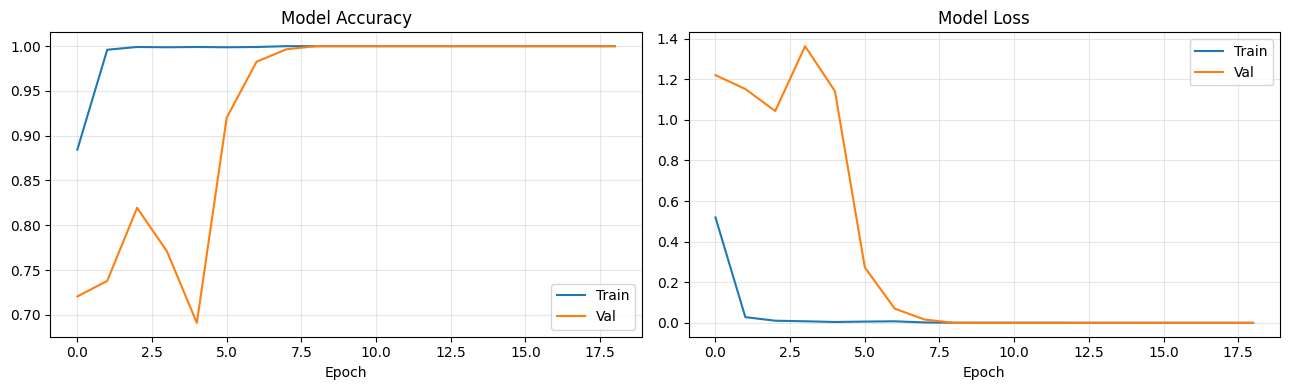

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, metric in zip(axes, ['accuracy', 'loss']):
    ax.plot(history.history[metric],           label='Train')
    ax.plot(history.history[f'val_{metric}'],  label='Val')
    ax.set_title(f'Model {metric.capitalize()}')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 📊 Step 8: Evaluate on Test Set


Test Accuracy : 100.00%
Test Loss     : 0.0002

Classification Report:
              precision    recall  f1-score   support

 Swipe Right       1.00      1.00      1.00       160
  Swipe Left       1.00      1.00      1.00       160
    Swipe Up       1.00      1.00      1.00       160
  Swipe Down       1.00      1.00      1.00       160
      Circle       1.00      1.00      1.00       160
  Tap/Zigzag       1.00      1.00      1.00       160

    accuracy                           1.00       960
   macro avg       1.00      1.00      1.00       960
weighted avg       1.00      1.00      1.00       960



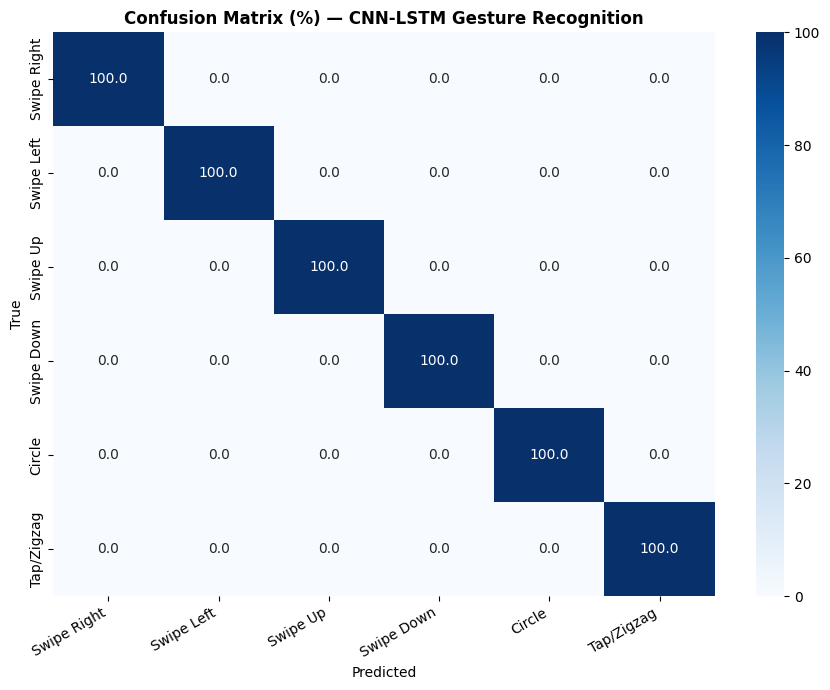

In [8]:
loss, acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f'\nTest Accuracy : {acc*100:.2f}%')
print(f'Test Loss     : {loss:.4f}')

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=GESTURE_NAMES))

cm = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1)[:, None] * 100

plt.figure(figsize=(9, 7))
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=GESTURE_NAMES, yticklabels=GESTURE_NAMES)
plt.title('Confusion Matrix (%) — CNN-LSTM Gesture Recognition', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 🔮 Step 9: Predict & Visualize a Single Gesture

/tmp/ipykernel_496/2952010978.py:37: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


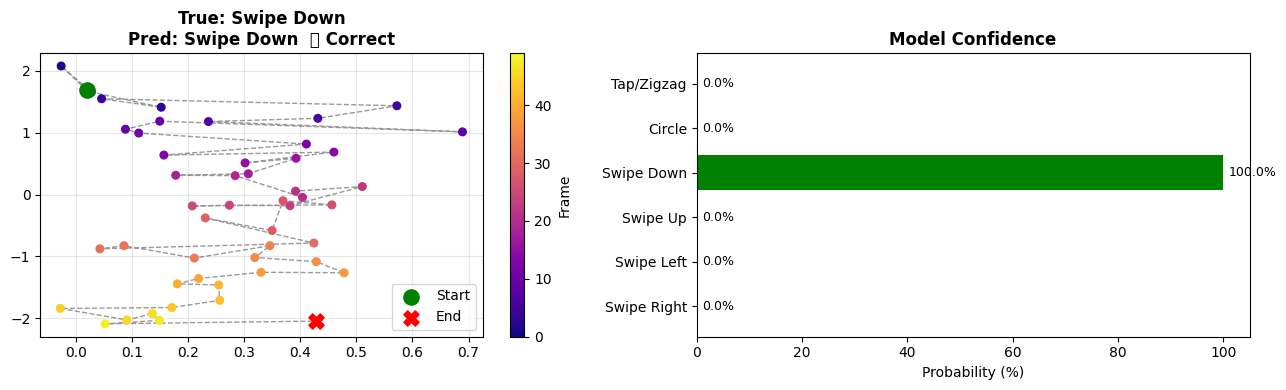

In [9]:
idx = np.random.randint(0, len(X_test))
sample     = X_test[idx:idx+1]
true_label = y_test[idx]

probs      = model.predict(sample, verbose=0)[0]
pred_label = np.argmax(probs)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: trajectory
traj = sample[0]  # (50, 2)
sc = axes[0].scatter(traj[:, 0], traj[:, 1],
                     c=np.arange(SEQ_LEN), cmap='plasma', s=30, zorder=3)
axes[0].plot(traj[:, 0], traj[:, 1], 'k--', alpha=0.4, linewidth=1)
axes[0].scatter(*traj[0],  color='green', s=120, zorder=5, label='Start')
axes[0].scatter(*traj[-1], color='red',   s=120, zorder=5, marker='X', label='End')
plt.colorbar(sc, ax=axes[0], label='Frame')
result = '✅ Correct' if pred_label == true_label else '❌ Wrong'
axes[0].set_title(
    f'True: {GESTURE_NAMES[true_label]}\nPred: {GESTURE_NAMES[pred_label]}  {result}',
    fontweight='bold'
)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: probability bar chart
bar_colors = ['green' if i == true_label else
              'red'   if i == pred_label  else
              'steelblue' for i in range(NUM_CLASSES)]
axes[1].barh(GESTURE_NAMES, probs * 100, color=bar_colors)
axes[1].set_xlabel('Probability (%)')
axes[1].set_title('Model Confidence', fontweight='bold')
axes[1].set_xlim(0, 105)
for i, p in enumerate(probs):
    axes[1].text(p * 100 + 1, i, f'{p*100:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 💾 Step 10: Save Model

In [10]:
model.save('cnn_lstm_gesture.h5')
print('✅ Model saved as cnn_lstm_gesture.h5')
try:
    from google.colab import files
    files.download('cnn_lstm_gesture.h5')
except:
    pass

✅ Model saved as cnn_lstm_gesture.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## ✅ Summary

| Component | Details |
|-----------|--------|
| **Dataset** | 100% Synthetic — generated with numpy |
| **Gestures** | 6 classes × 800 samples = 4800 total |
| **Input** | 50 timesteps × 2 features (x, y) |
| **CNN** | 2 blocks — detect local trajectory patterns |
| **LSTM** | 2 layers — model full gesture shape over time |
| **Expected Acc** | ~97–99% |

### 💡 Why Generated Data Works Here:
- Gestures have **mathematically distinct shapes** (line vs circle vs zigzag)
- Added **realistic noise** simulates hand tremor
- Random **scale + shift** augmentation makes it robust

### 🔥 Ideas to Extend:
- Add more gestures (Z-shape, triangle, double-tap)
- Use **MediaPipe** to collect real hand data
- Deploy with webcam for **real-time smart home control**
- Add velocity (dx, dy) as extra features → 4 features per frame